# Credit Card Fraud Detection - Exploratory Data Analysis

## Project Overview

This notebook performs an exploratory data analysis (EDA) of the Credit Card Fraud Detection dataset. The purpose of this analysis is to understand the dataset, identify potential data quality issues, examine feature distributions, and investigate characteristics of fraudulent and legitimate transactions.

The findings from this notebook will guide the preprocessing pipeline and model development stages of the MLOps project.

## Notebook Contents

1. Project Overview
2. Import Libraries
3. Load Dataset
4. Dataset Overview
5. Data Quality Assessment
6. Target Variable Analysis
7. Feature Exploration
   - Transaction Amount
   - Transaction Time
   - PCA Features
8. Correlation Analysis
9. Outlier Analysis
10. Key Findings
11. Next Steps

## Import Libraries

In [51]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt

from pathlib import Path

plt.style.use("ggplot")

DATA_PATH = Path("../data/raw/creditcard.csv")
FIGURES_PATH = Path("../reports/figures")

# Create the folder if it doesn't exist
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

## Load Dataset

In [2]:
DATA_PATH = Path("../data/raw/creditcard.csv")

df = pd.read_csv(DATA_PATH)
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Basic shape

In [15]:
print(f"Dataset Shape: {df.shape}")

Dataset Shape: (284807, 31)


## Dataset Overview

The dataset contains anonymized credit card transactions made by European cardholders.

### Features

- Time
- Amount
- V1–V28 (Principal Component Analysis transformed features)
- Class (Target)

The target variable indicates whether a transaction is fraudulent:

- 0 → Legitimate
- 1 → Fraudulent

Column information

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [16]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


In [45]:
summary = pd.DataFrame({
    "Property": [
        "Rows",
        "Columns",
        "Fraud Cases",
        "Legitimate Cases",
        "Missing Values",
        "Duplicate Rows"
    ],
    "Value": [
        len(df),
        df.shape[1],
        df["Class"].sum(),
        len(df)-df["Class"].sum(),
        df.isnull().sum().sum(),
        df.duplicated().sum()
    ]
})

summary

,Property,Value
0,Rows,284807
1,Columns,31
2,Fraud Cases,492
3,Legitimate Cases,284315
4,Missing Values,0
5,Duplicate Rows,1081


## Data Quality Assessment

The quality of the dataset is evaluated by checking:

- Missing values
- Duplicate records
- Data types

Missing values

In [17]:
missing = df.isnull().sum()

missing[missing > 0]

Series([], dtype: int64)

Duplicates

In [18]:
duplicates = df.duplicated().sum()

print(f"Duplicate rows: {duplicates}")

Duplicate rows: 1081


### Observations

- No missing values were detected.
- The dataset contains duplicate transactions.
- Duplicate records will be investigated during preprocessing before deciding whether they should be removed.

## Target Variable Analysis

Class Counts

In [42]:
class_counts = df["Class"].value_counts()

class_counts

Class
0    284315
1       492
Name: count, dtype: int64

Class Percentage

In [43]:
(class_counts / len(df) * 100).round(3)

Class
0    99.827
1     0.173
Name: count, dtype: float64

Bar Chart Plot Class Distribution

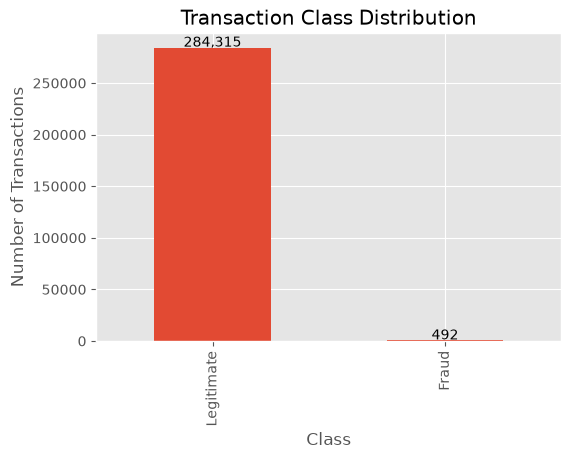

In [47]:
ax = class_counts.plot(kind="bar", figsize=(6,4))

for i, v in enumerate(class_counts):
    ax.text(i, v + 1000, f"{v:,}", ha="center")

plt.title("Transaction Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Transactions")
plt.xticks([0,1],["Legitimate","Fraud"])

# Save the figure
plt.savefig(
    FIGURES_PATH / "class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

# Display the figure
plt.show()

### Observations

The dataset is highly imbalanced.

Approximately 99.8% of transactions are legitimate, while only 0.2% are fraudulent.

This imbalance must be considered during model development because traditional accuracy can be misleading. Metrics such as Precision, Recall, F1-score, ROC-AUC, and PR-AUC will be more appropriate.

## Feature Exploration

Amount Statistics

In [9]:
df["Amount"].describe()

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

Histogram of Amount

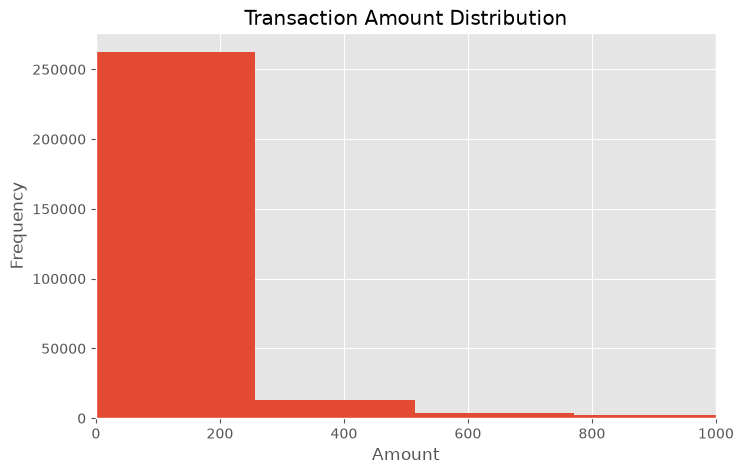

In [48]:
plt.figure(figsize=(8,5))

plt.hist(df["Amount"], bins=100)

plt.xlim(0, 1000)

plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")

# Save the figure
plt.savefig(
    FIGURES_PATH / "amount_distribution.png",
    dpi=300,
    bbox_inches="tight")

plt.show()

Boxplot

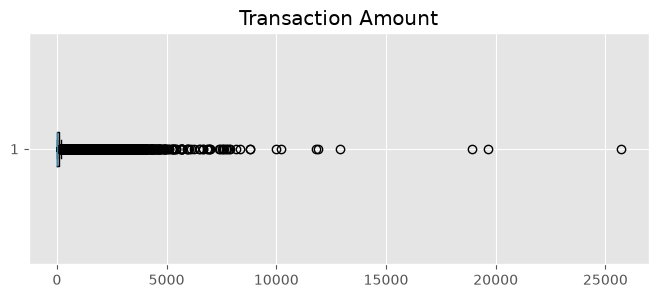

In [33]:
plt.figure(figsize=(8,3))

plt.boxplot(df["Amount"], vert=False)

plt.title("Transaction Amount")

# Save the figure
plt.savefig(
    FIGURES_PATH / "amount_boxplot.png",
    dpi=300,
    bbox_inches="tight")

plt.show()

Histogram of Fraud Amounts

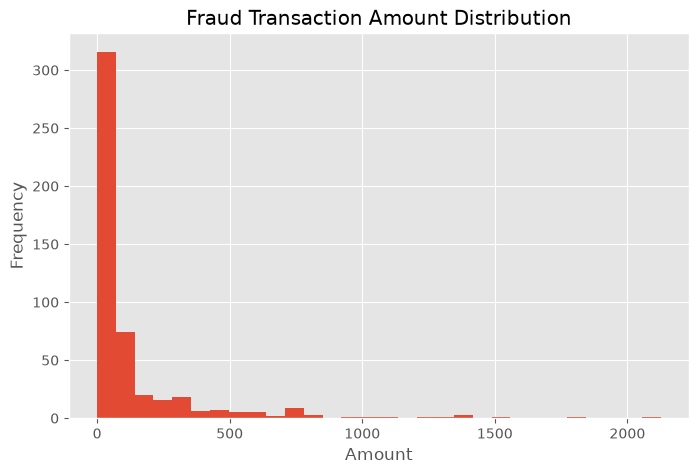

In [34]:
fraud = df[df["Class"] == 1]

plt.figure(figsize=(8,5))
plt.hist(fraud["Amount"], bins=30)
plt.title("Fraud Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")

# Save the figure
plt.savefig(
    FIGURES_PATH / "fraud_amount_distribution.png",
    dpi=300,
    bbox_inches="tight")

plt.show()

Compare Amount by Class: Fraud vs Legitimate

In [24]:
df.groupby("Class")["Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


## Transaction Time Analysis

The `Time` feature represents the elapsed time in seconds between each transaction and the first transaction in the dataset.

Although it does not correspond to an actual timestamp, analyzing its distribution helps identify whether transactions are spread uniformly across the observation period.

Summary Statistics

In [25]:
df["Time"].describe()

count    284807.000000
mean      94813.859575
std       47488.145955
min           0.000000
25%       54201.500000
50%       84692.000000
75%      139320.500000
max      172792.000000
Name: Time, dtype: float64

Histogram

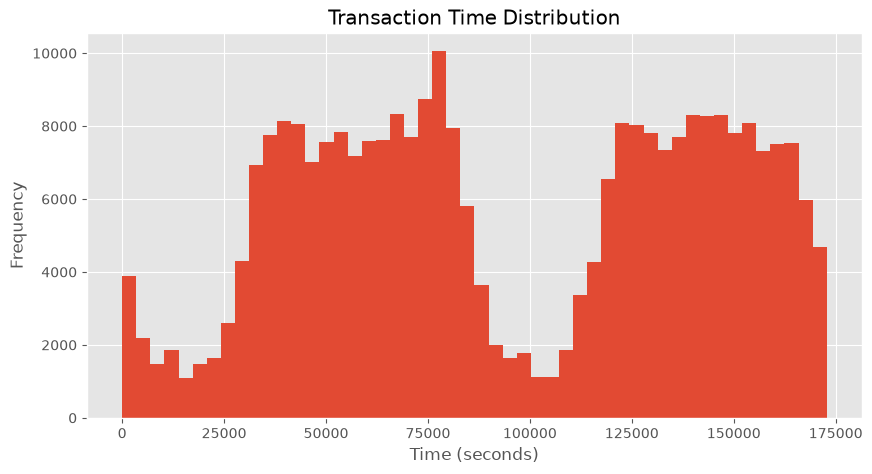

In [35]:
plt.figure(figsize=(10,5))

plt.hist(df["Time"], bins=50)

plt.title("Transaction Time Distribution")
plt.xlabel("Time (seconds)")
plt.ylabel("Frequency")

plt.savefig(
    FIGURES_PATH / "time_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Fraud vs Legitimate Time

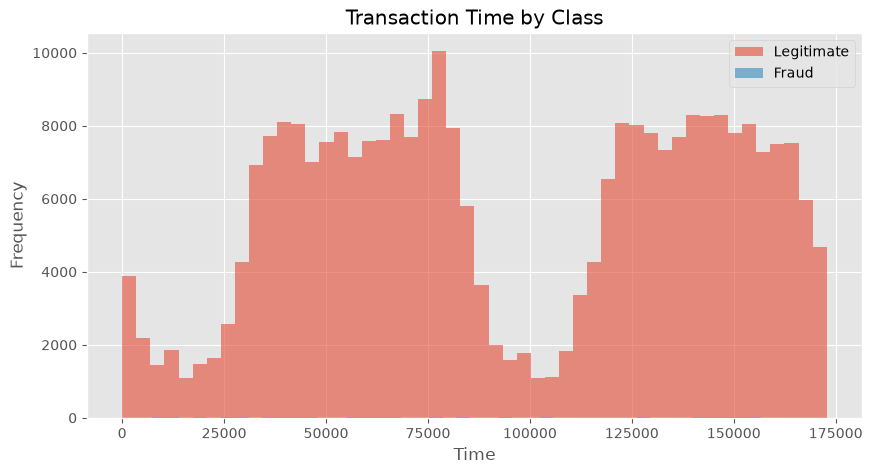

In [36]:
plt.figure(figsize=(10,5))

plt.hist(
    df[df["Class"] == 0]["Time"],
    bins=50,
    alpha=0.6,
    label="Legitimate"
)

plt.hist(
    df[df["Class"] == 1]["Time"],
    bins=50,
    alpha=0.6,
    label="Fraud"
)

plt.legend()

plt.title("Transaction Time by Class")
plt.xlabel("Time")
plt.ylabel("Frequency")

plt.savefig(
    FIGURES_PATH / "time_by_class.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observations

Transaction times appear to be distributed throughout the observation period for both legitimate and fraudulent transactions.

At first glance, the `Time` feature alone does not clearly distinguish fraudulent transactions, although it may still contribute useful information when combined with other features.

## PCA Feature Exploration

Boxplots by Class

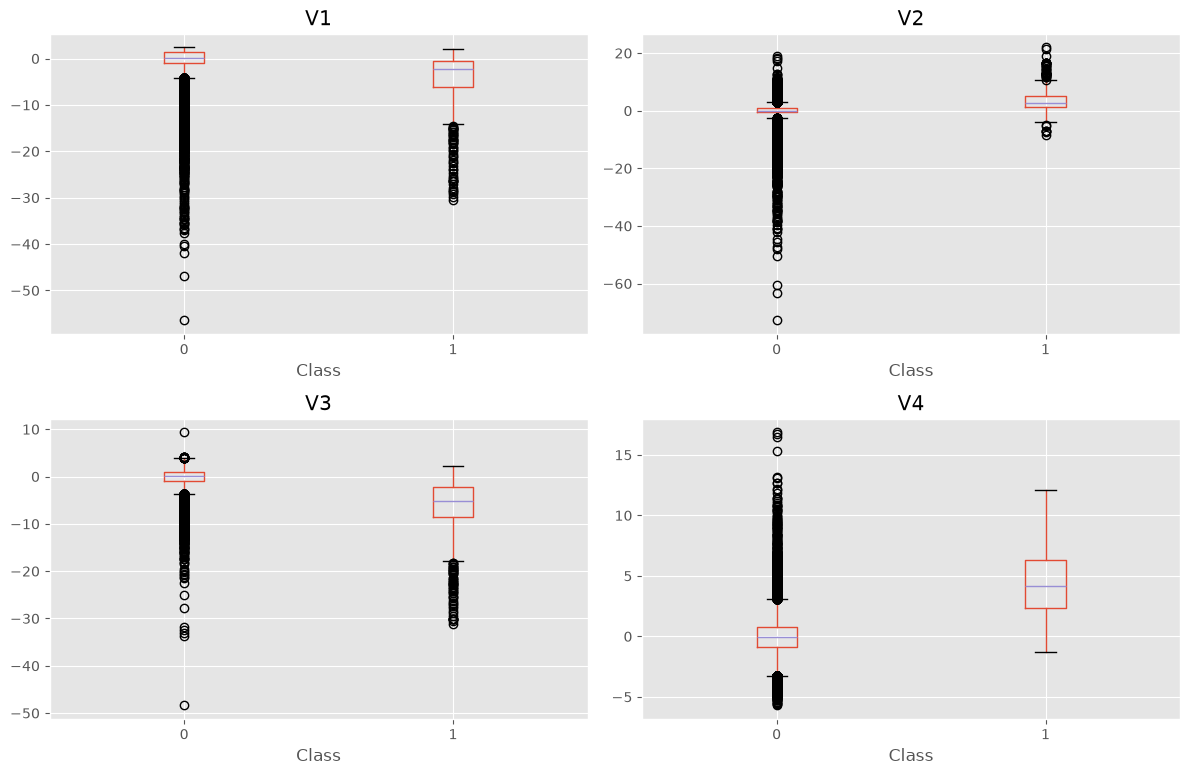

In [37]:
features = ["V1", "V2", "V3", "V4"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, feature in zip(axes.flatten(), features):
    df.boxplot(column=feature, by="Class", ax=ax)
    ax.set_title(feature)

plt.suptitle("")

plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "pca_features_boxplots.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observations

Several PCA-transformed features exhibit noticeably different distributions between legitimate and fraudulent transactions.

This suggests that these anonymized features contain valuable information for distinguishing fraud and are expected to contribute significantly to model performance.

## Correlation Analysis

Correlation analysis helps identify which features have the strongest linear relationship with the target variable, `Class`.

Because the dataset contains 31 columns, a full correlation heatmap would be difficult to read. Instead, this analysis focuses on the features most strongly correlated with fraudulent transactions.

In [38]:
correlation = df.corr(numeric_only=True)["Class"].sort_values()

correlation.tail(10)

V28      0.009536
V27      0.017580
V8       0.019875
V20      0.020090
V19      0.034783
V21      0.040413
V2       0.091289
V4       0.133447
V11      0.154876
Class    1.000000
Name: Class, dtype: float64

### Top Positive Correlations

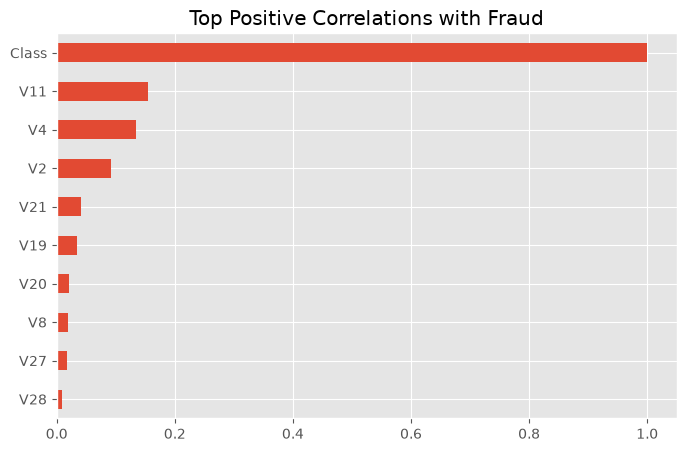

In [39]:
correlation.tail(10).plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Top Positive Correlations with Fraud")

plt.savefig(
    FIGURES_PATH / "positive_correlations.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Top Negative Correlations

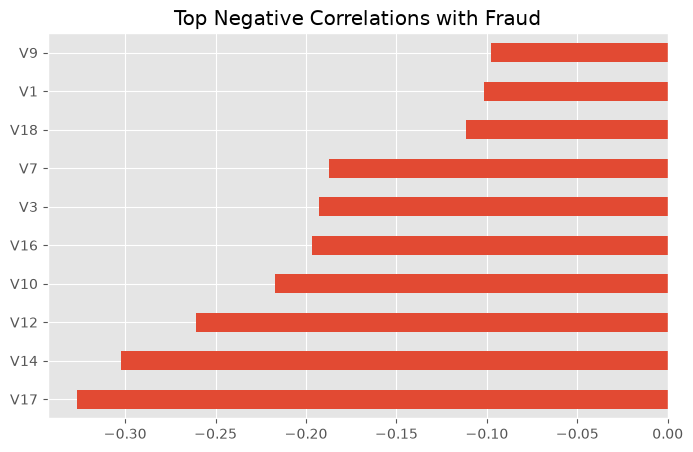

In [40]:
correlation.head(10).plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Top Negative Correlations with Fraud")

plt.savefig(
    FIGURES_PATH / "negative_correlations.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Get the Top Correlated Features

In [49]:
# Correlation of all features with the target variable
correlation = df.corr(numeric_only=True)["Class"].sort_values()

# Select the 10 features most strongly correlated with the target
top_features = correlation.abs().sort_values(ascending=False).head(11).index

top_features

Index(['Class', 'V17', 'V14', 'V12', 'V10', 'V16', 'V3', 'V7', 'V11', 'V4',
       'V18'],
      dtype='object')

### Correlation Heatmap

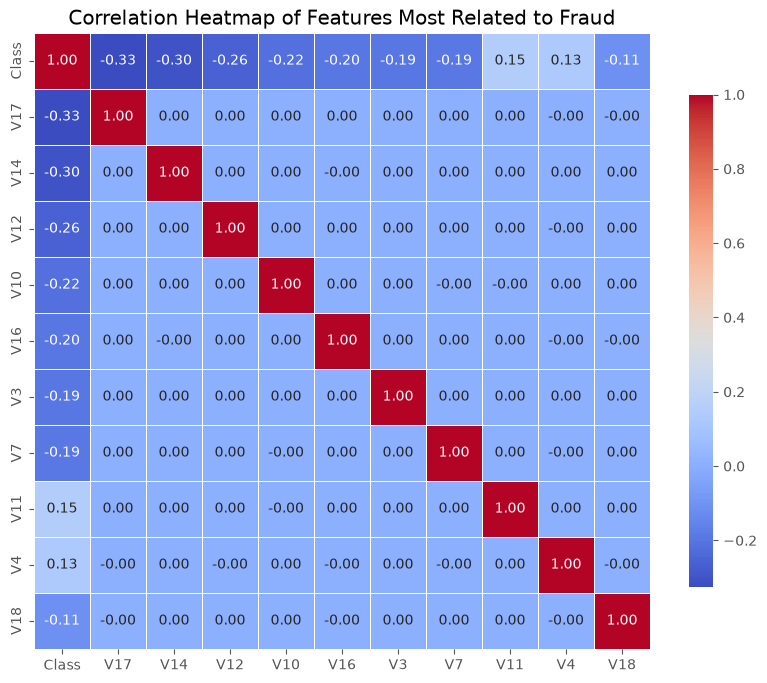

In [52]:
# Correlation matrix for the selected features
corr_matrix = df[top_features].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Heatmap of Features Most Related to Fraud")

plt.savefig(
    FIGURES_PATH / "top_feature_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observations

To improve readability, the heatmap displays only the features with the strongest correlations to the target variable (`Class`).

Several PCA-transformed features show stronger relationships with fraudulent transactions than `Time` or `Amount`. These features will be retained for model training.

Although the `Amount` feature has a relatively weak linear correlation with the target, it may still contribute useful information when combined with other variables.

## Outlier Analysis

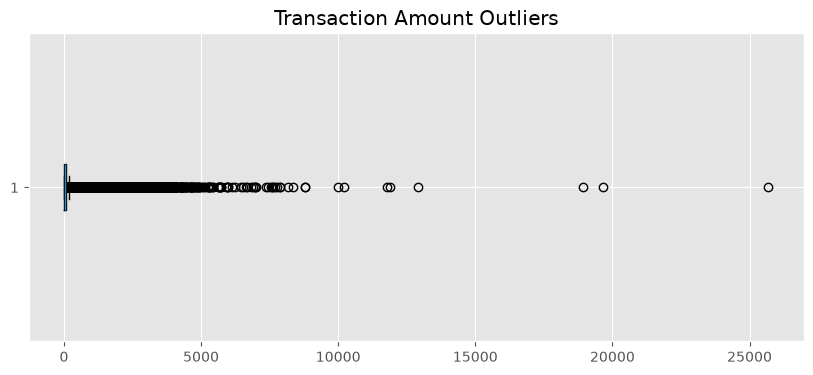

In [41]:
plt.figure(figsize=(10,4))

plt.boxplot(df["Amount"], vert=False)

plt.title("Transaction Amount Outliers")

plt.savefig(
    FIGURES_PATH / "amount_outliers.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observations

The transaction amount contains numerous extreme values.

Since financial datasets naturally include high-value transactions, these observations will not be removed during exploratory analysis. Instead, appropriate feature scaling techniques (e.g., `RobustScaler`) will be evaluated during preprocessing.

## Key Findings

- The dataset contains **284,807** transactions and **31** features.
- No missing values were detected.
- **1,081 duplicate rows** were identified and will be evaluated during preprocessing.
- The dataset is **highly imbalanced**, with fraudulent transactions representing approximately **0.17%** of all observations.
- Several PCA-transformed features show clear differences between fraudulent and legitimate transactions.
- The `Amount` feature contains significant outliers that should be handled through scaling rather than removal.
- Due to the class imbalance, evaluation metrics such as Precision, Recall, F1-score, ROC-AUC, and PR-AUC will be prioritized over accuracy.
- Fraudulent transactions represent only 0.17% of the data, making this a highly imbalanced classification problem that will require careful model evaluation.

## Next Steps

The next stage of the project is data preprocessing, which will include:

- Removing unnecessary duplicates (if justified).
- Scaling numerical features.
- Creating train/validation/test datasets.
- Saving processed data.
- Integrating preprocessing into the DVC pipeline.

## Conclusion

The exploratory analysis provided valuable insights into the credit card fraud dataset. The data is complete, contains no missing values, and consists primarily of anonymized PCA-transformed features. The severe class imbalance represents the primary challenge for model development.

The findings from this analysis will guide the preprocessing pipeline, feature scaling strategy, model selection, and evaluation metrics in the next phase of the project.